In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import os


In [2]:
# Load the news datasets
Fake_df = pd.read_csv('raw_dataset/news_dataset/Fake.csv')
True_df = pd.read_csv('raw_dataset/news_dataset/True.csv')


In [3]:
# Display basic info about the fake news df
print("FAKE NEWS DATASET")
print(f"Shape: {Fake_df.shape}")
print(f"\nColumns: {Fake_df.columns.tolist()}")
print(f"\nFirst few rows: {Fake_df.head()}")
print(f"\nData types: {Fake_df.dtypes}")
print(f"\nMissing values: {Fake_df.isnull().sum()}")
print(f"\nDuplicated rows: {Fake_df.duplicated().sum()}")

FAKE NEWS DATASET
Shape: (23481, 4)

Columns: ['title', 'text', 'subject', 'date']

First few rows:                                                title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  

Data types: title      object
text     

In [4]:
# Display basic info about the true news df

print("TRUE NEWS DATASET")
print(f"Shape: {True_df.shape}")
print(f"\nColumns: {True_df.columns.tolist()}")
print(f"\nFirst few rows: {True_df.head()}")
print(f"\nData types: {True_df.dtypes}")
print(f"\nMissing values: {True_df.isnull().sum()}")
print(f"\nDuplicated rows: {True_df.duplicated().sum()}")

TRUE NEWS DATASET
Shape: (21417, 4)

Columns: ['title', 'text', 'subject', 'date']

First few rows:                                                title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017  

In [5]:
# Cleanup datasets
Fake_df.drop_duplicates(inplace=True)
True_df.drop_duplicates(inplace=True)

print(f"\nFake news Duplicated rows: {Fake_df.duplicated().sum()}")
print(f"\nTrue news Duplicated rows: {True_df.duplicated().sum()}")


Fake news Duplicated rows: 0

True news Duplicated rows: 0


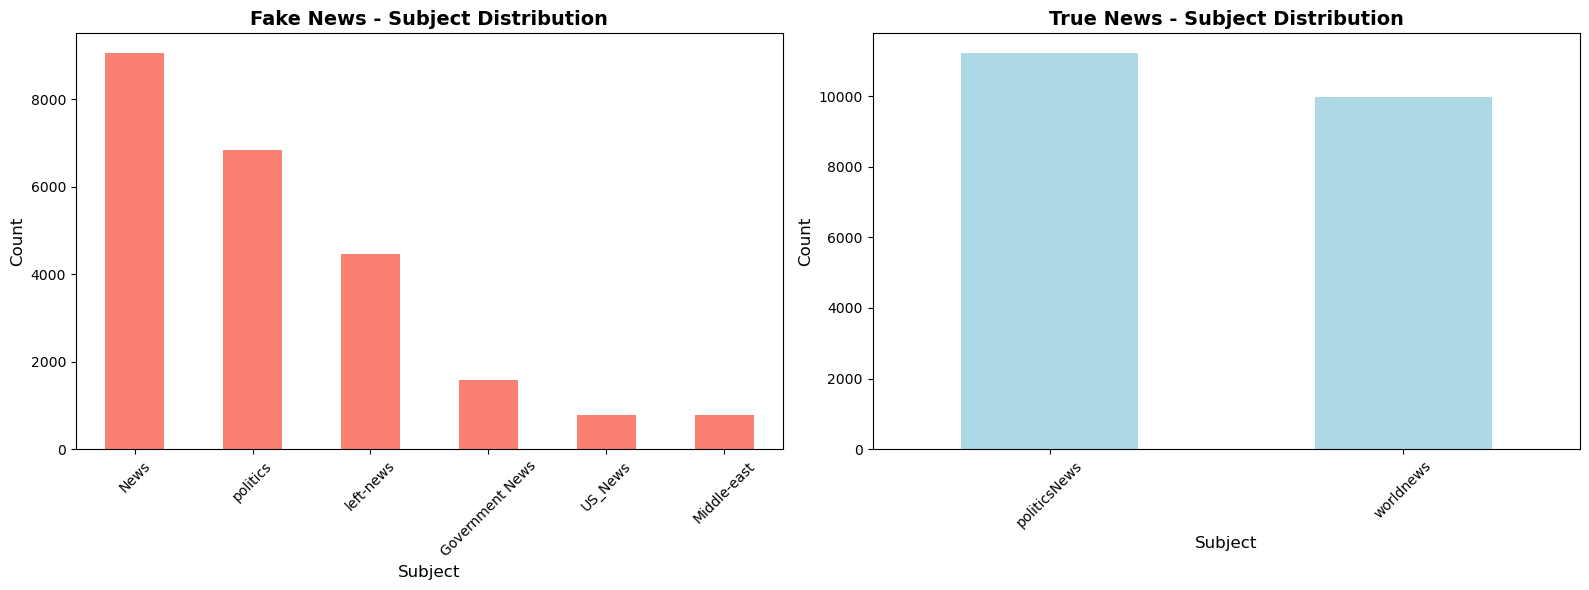

In [6]:
# EDA
# Analyze subject distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


# Fake news subjects
Fake_df['subject'].value_counts().plot(kind='bar', ax=axes[0], color='salmon')
axes[0].set_title('Fake News - Subject Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Subject', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# True news subjects
True_df['subject'].value_counts().plot(kind='bar', ax=axes[1], color='lightblue')
axes[1].set_title('True News - Subject Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Subject', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Convert date to datetime and extract year for time-based analysis
Fake_df['date'] = pd.to_datetime(Fake_df['date'], errors='coerce')
True_df['date'] = pd.to_datetime(True_df['date'], errors='coerce')

Fake_df['year'] = Fake_df['date'].dt.year
True_df['year'] = True_df['date'].dt.year

print("Date columns converted to datetime")
print(f"\nFake News date range: {Fake_df['date'].min()} to {Fake_df['date'].max()}")
print(f"True News date range: {True_df['date'].min()} to {True_df['date'].max()}")
print(f"\nFake News year range: {Fake_df['year'].min()} to {Fake_df['year'].max()}")
print(f"True News year range: {True_df['year'].min()} to {True_df['year'].max()}")

Date columns converted to datetime

Fake News date range: 2015-05-01 00:00:00 to 2017-12-31 00:00:00
True News date range: 2016-01-13 00:00:00 to 2017-12-31 00:00:00

Fake News year range: 2015.0 to 2017.0
True News year range: 2016 to 2017


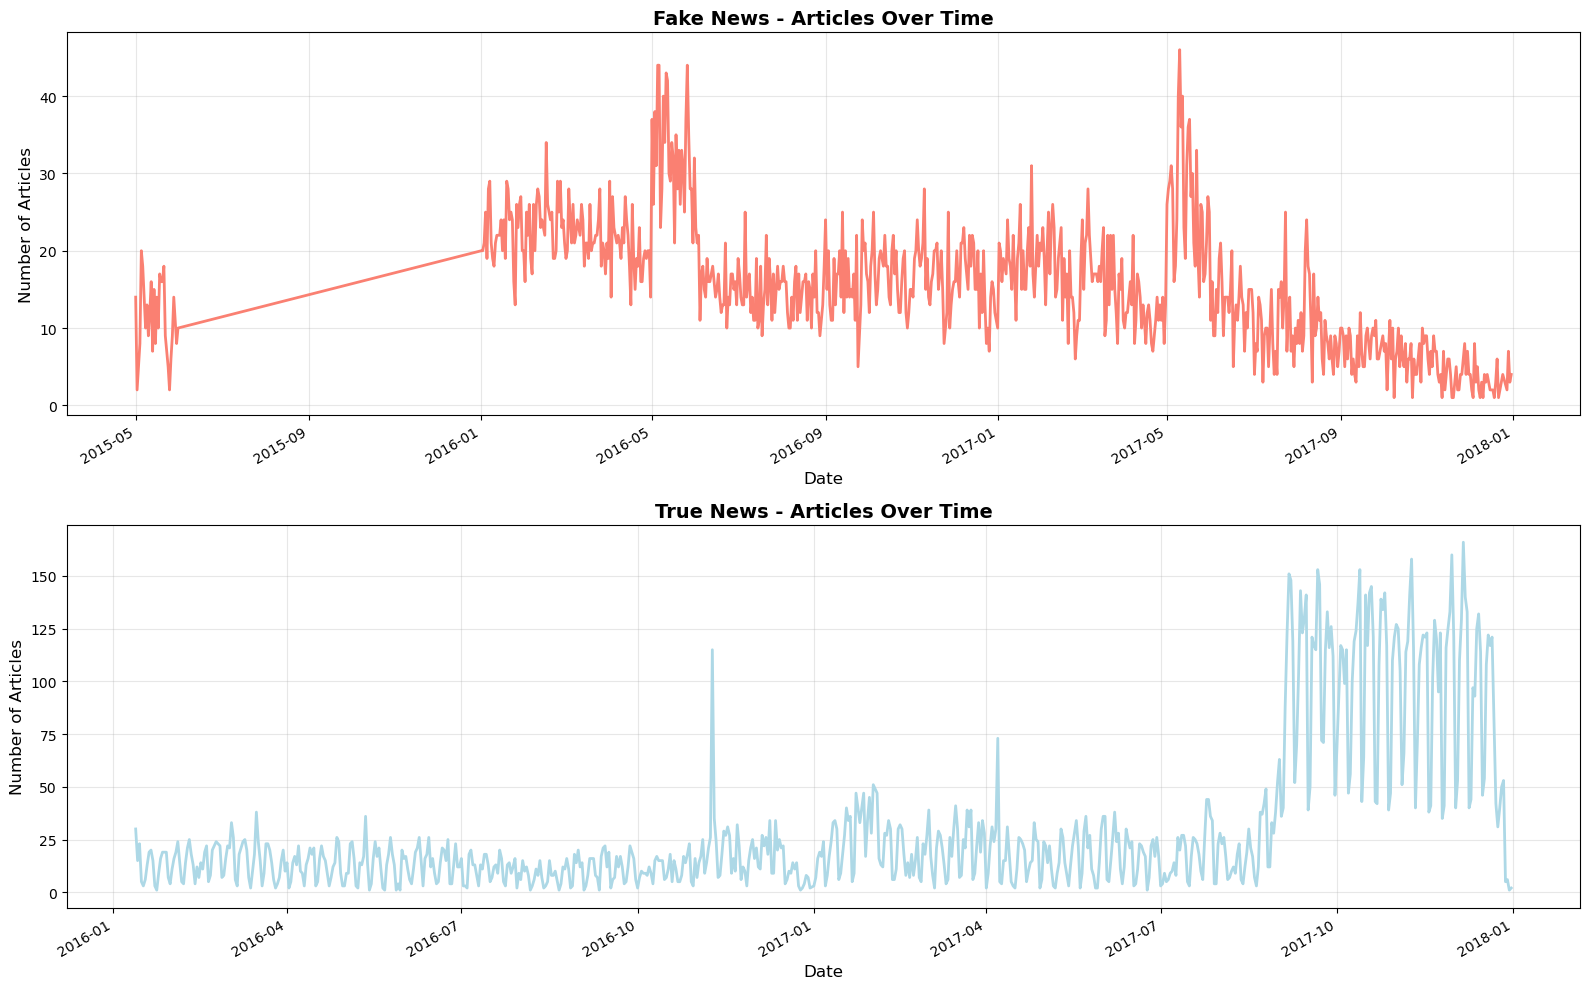

In [8]:
# EDA cont.
# Analyze date occurrences over time
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Fake news over time
Fake_df['date'].value_counts().sort_index().plot(ax=axes[0], color='salmon', linewidth=2)
axes[0].set_title('Fake News - Articles Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Date', fontsize=12)
axes[0].set_ylabel('Number of Articles', fontsize=12)
axes[0].grid(True, alpha=0.3)

# True news over time
True_df['date'].value_counts().sort_index().plot(ax=axes[1], color='lightblue', linewidth=2)
axes[1].set_title('True News - Articles Over Time', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Date', fontsize=12)
axes[1].set_ylabel('Number of Articles', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

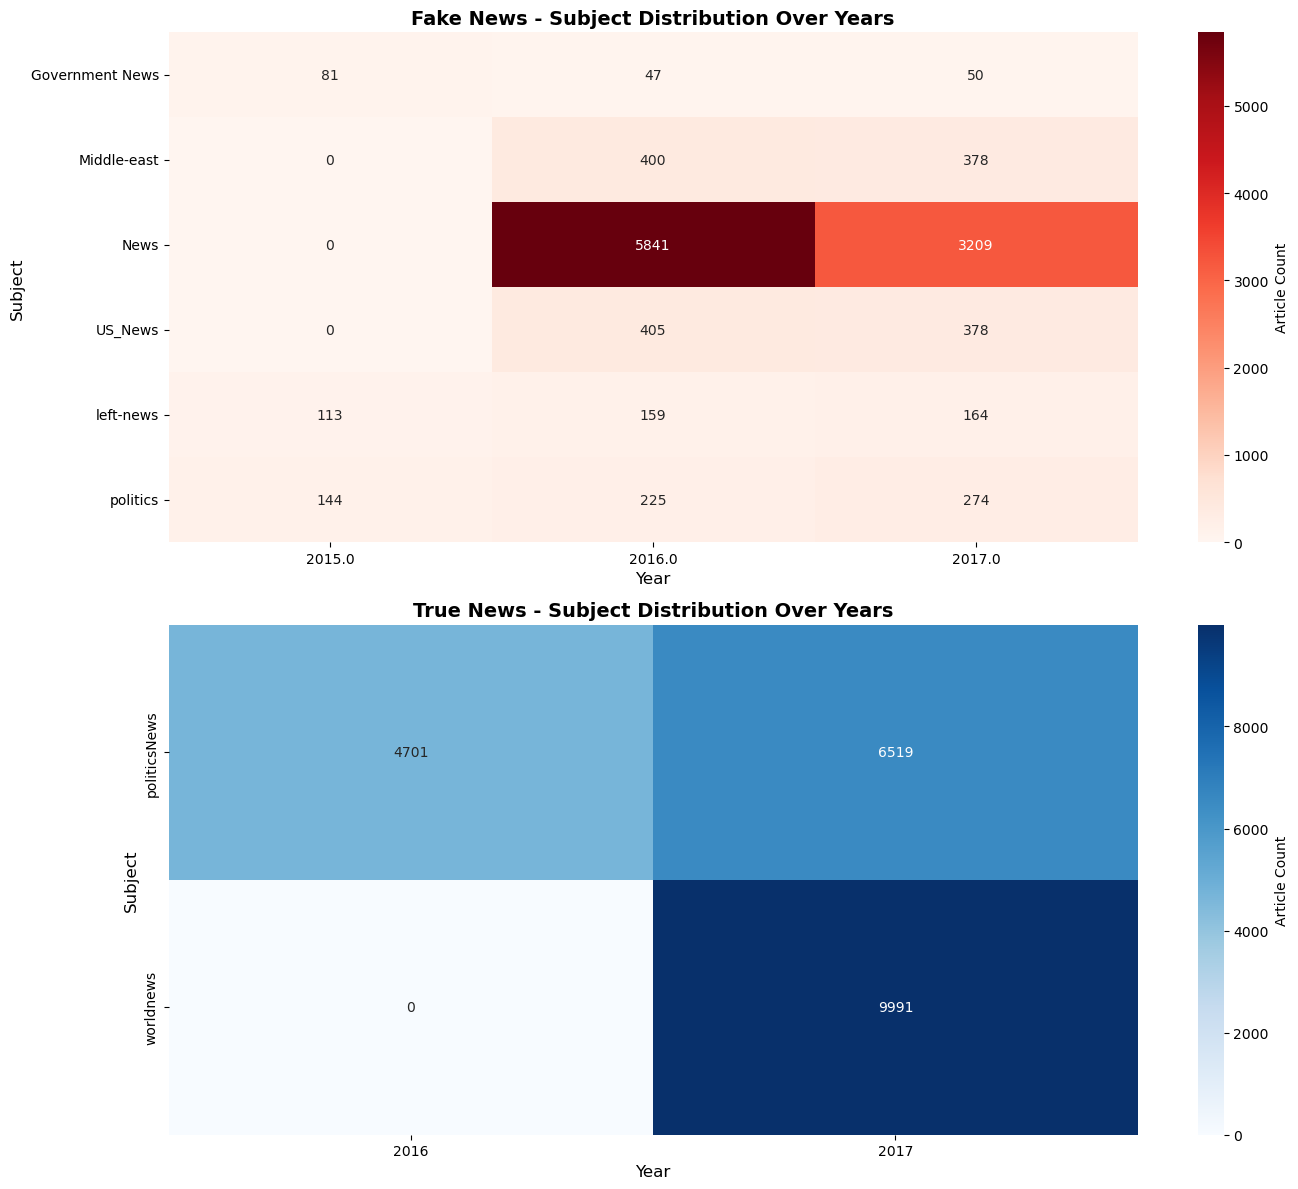

In [9]:
# Visualize subject trends over time with heatmaps
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

fake_subject_year = pd.crosstab(Fake_df['year'], Fake_df['subject'])
true_subject_year = pd.crosstab(True_df['year'], True_df['subject'])

# Fake news heatmap
sns.heatmap(fake_subject_year.T, annot=True, fmt='d', cmap='Reds', ax=axes[0], cbar_kws={'label': 'Article Count'})
axes[0].set_title('Fake News - Subject Distribution Over Years', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Subject', fontsize=12)

# True news heatmap
sns.heatmap(true_subject_year.T, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar_kws={'label': 'Article Count'})
axes[1].set_title('True News - Subject Distribution Over Years', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Subject', fontsize=12)

plt.tight_layout()
plt.show()

In [10]:
# clean the formats

subject_mapping = {
    'left-news': 'left',
    'US_News': "us",
    'Government News': "government",
    'politicsNews': 'politics',
    'worldnews': 'news'
}

def clean_format(text):
    text = str(text).strip().lower()
    return text

def clean_content(text):
    text = str(text).strip().lower()
    tokens = word_tokenize(text)
    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word.isalnum() and word not in stop_words]
    lemmatizer = WordNetLemmatizer()
    lemmatized = [lemmatizer.lemmatize(token) for token in tokens]
    return ' '.join(lemmatized)

In [11]:
Fake_df['label'] = False
True_df['label'] = True
news_df = pd.concat([Fake_df,True_df],axis=0, ignore_index=True)
news_df.head()

,title,text,subject,date,year,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31,2017.0,False
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31,2017.0,False
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30,2017.0,False
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29,2017.0,False
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25,2017.0,False


In [12]:
# applying functions and mapping
news_df['subject'] = news_df['subject'].replace(subject_mapping)
news_df['cleaned_title'] = news_df['title'].apply(lambda x: clean_format(x))
news_df['cleaned_text'] = news_df['text'].apply(lambda x: clean_content(x))


In [14]:
news_df.head()

,title,text,subject,date,year,label,cleaned_title,cleaned_text
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,2017-12-31,2017.0,False,donald trump sends out embarrassing new year’s...,donald trump wish american happy new year leav...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,2017-12-31,2017.0,False,drunk bragging trump staffer started russian c...,house intelligence committee chairman devin nu...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,2017-12-30,2017.0,False,sheriff david clarke becomes an internet joke ...,friday revealed former milwaukee sheriff david...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,2017-12-29,2017.0,False,trump is so obsessed he even has obama’s name ...,christmas day donald trump announced would bac...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,2017-12-25,2017.0,False,pope francis just called out donald trump duri...,pope francis used annual christmas day message...


In [ ]:
os.makedirs('cleaned_dataset', exist_ok=True)
news_df.to_csv('cleaned_dataset/combined_news.csv', index=False)
